In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# directories
working_dir = "/Users/natsudanav/Desktop/PRIMEloci/evaluation/model_evaluation"
model_dir = "/Users/natsudanav/Documents/data_PRIMEloci_dev/model_PRIMEloci/PRIMEloci_GM12878_model_1.0.sav"

os.chdir(working_dir)

In [3]:
# Load the trained model
with open(model_dir, 'rb') as file:
    model = pickle.load(file)

/Users/natsudanav/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.2.1 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


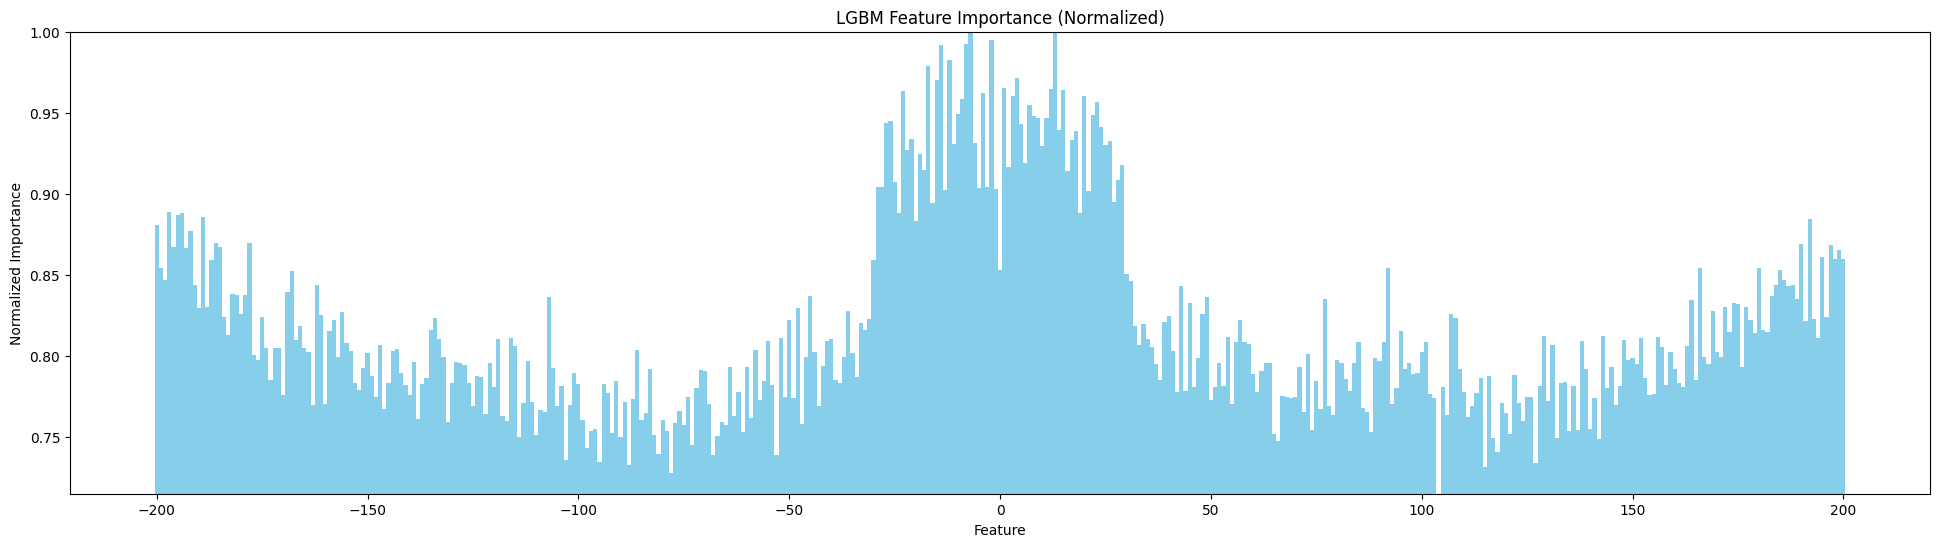

In [4]:
# Extract feature names and importance scores
feature_importances = pd.DataFrame({
    'Feature': model.feature_name_,  # Original feature names
    'Importance': model.feature_importances_
})

# Normalize importance scores to range [0, 1]
feature_importances['Normalized Importance'] = feature_importances['Importance'] / feature_importances['Importance'].max()

# Map column indices (0-400) to positions (-200 to 200)
feature_importances['Feature'] = range(-200, 201)  # Map directly from -200 to 200

# Get the minimum importance value
min_importance = feature_importances['Normalized Importance'].min()

# Sort by importance to get the top 20 features
top_20_features = feature_importances.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 features sorted by position
top_20_features_sorted = top_20_features.sort_values(by='Feature')  # Sort by position (-200 to 200)

# Plot normalized feature importance
plt.figure(figsize=(24, 6))
plt.bar(
    feature_importances['Feature'],
    feature_importances['Normalized Importance'],
    color='skyblue',
    width=1.0)
# Dark blue for top 20 features
plt.bar(
    top_20_features['Feature'], 
    top_20_features['Normalized Importance'], 
    color='skyblue', 
    width=1.0,
    label='Top 20 Features'
)
plt.xlabel('Feature')
plt.ylabel('Normalized Importance')
plt.title('LGBM Feature Importance (Normalized)')
plt.xticks(ticks=range(-200, 201, 50))  # Add ticks for readability
plt.ylim(min_importance, 1)  # Set y-axis to start from the minimum importance
plt.savefig("feature_importance_normalized.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

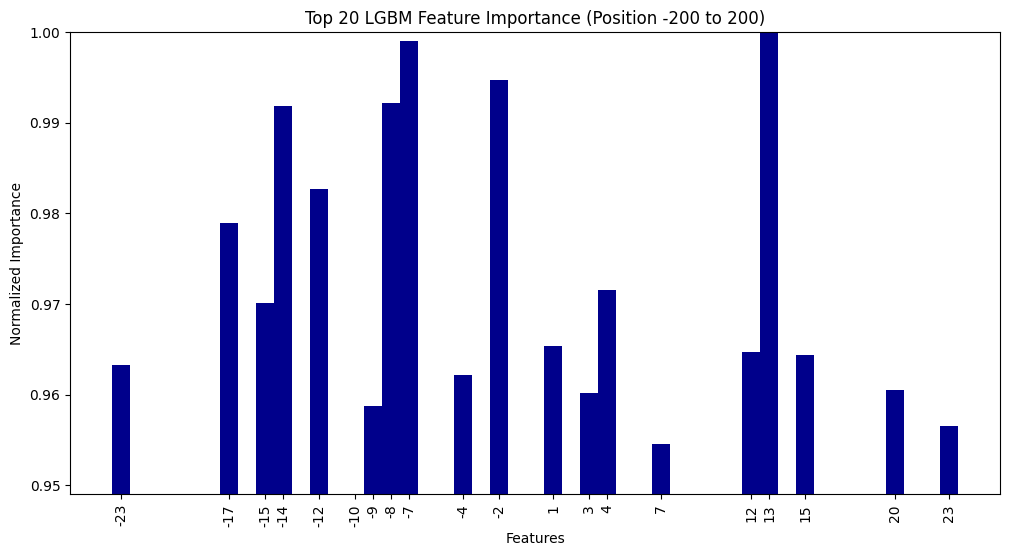

Top 20 Features with Corresponding Positions:
     Feature  Importance  Normalized Importance
177      -23        6025               0.963229
183      -17        6123               0.978897
185      -15        6068               0.970104
186      -14        6204               0.991847
188      -12        6147               0.982734
190      -10        5936               0.949001
191       -9        5997               0.958753
192       -8        6206               0.992166
193       -7        6249               0.999041
196       -4        6018               0.962110
198       -2        6222               0.994724
201        1        6038               0.965308
203        3        6006               0.960192
204        4        6077               0.971543
207        7        5971               0.954596
212       12        6034               0.964668
213       13        6255               1.000000
215       15        6032               0.964349
220       20        6008               0.9

In [5]:
# Plot top 20 feature importance
plt.figure(figsize=(12, 6))
plt.bar(top_20_features_sorted['Feature'], top_20_features_sorted['Normalized Importance'], color='darkblue', width=1.0)
plt.xlabel('Features')
plt.ylabel('Normalized Importance')
plt.title('Top 20 LGBM Feature Importance (Position -200 to 200)')
plt.xticks(
    ticks=top_20_features_sorted['Feature'],  # Use the sorted positions as ticks
    labels=top_20_features_sorted['Feature'],  # Use sorted positions as labels
    rotation=90
)

#plt.xticks(ticks=top_20_features_sorted['Feature'], labels=top_20_features_sorted['Feature'], rotation=90)
plt.ylim(top_20_features_sorted['Normalized Importance'].min(), 1)  # Set y-axis to start from min of top 20
plt.savefig("feature_importance_normalized_top20.pdf", format="pdf", bbox_inches="tight", dpi=300)
plt.show()

# Print top 20 feature details
print("Top 20 Features with Corresponding Positions:")
print(top_20_features_sorted[['Feature', 'Importance', 'Normalized Importance']])